# 07b — Forecast con Prophet: Proyecciones de Market Share 2025-2027

> **Fase 3 (componente predictivo) — Framework Intelligence-to-Action (I2A)**

## Objetivo

Proyectar el **dominio relativo** (Market Share) de tecnologias seleccionadas **36 meses hacia el futuro** (enero 2025 a diciembre 2027) para respaldar decisiones curriculares concretas para UNIANDES.

### El problema del volumen absoluto y el "Efecto IA"

Desde la irrupcion de la IA generativa (ChatGPT, GitHub Copilot), el volumen absoluto de preguntas en Stack Overflow ha caido drasticamente en **todas** las tecnologias. Si proyectaramos el conteo bruto, Prophet predeciria un falso declive universal que no refleja cambios reales en la relevancia relativa de cada tecnologia.

### Solucion: Market Share Mensual

En lugar de proyectar el volumen absoluto, calculamos el **Porcentaje Relativo Mensual** (Market Share):

$$\text{Market Share}_{\text{tag}, t} = \frac{\text{Preguntas del Tag en el mes } t}{\text{Total de preguntas de TODOS los tags en el mes } t} \times 100$$

Esta metrica es **inmune a la caida global** de volumen: si Python pasa del 8% al 10% del total, su relevancia relativa crece independientemente de cuantas preguntas haya en la plataforma.

> **Advertencia:** Este cuaderno requiere `pip install prophet` (o `conda install prophet`).

In [7]:
import polars as pl
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import warnings
import sys, os

warnings.filterwarnings('ignore')  # Suprimir warnings de cmdstanpy

# Importar funciones modulares de forecasting
sys.path.append(os.path.abspath('..'))
from src.forecast import entrenar_modelo_prophet, evaluar_ajuste, proyectar_futuro

# Rutas
CLASIF_PATH = '../data/datos_procesados/eda/clasificacion.parquet'
DIM_Q       = '../data/datos_procesados/dim_questions.parquet'
FACT_T      = '../data/datos_procesados/fact_question_tags.parquet'
OUT_DIR     = '../data/datos_procesados/eda'

---

## 1 - Seleccion Estrategica de Tags

No proyectamos los 20 tags. Seleccionamos unicamente tecnologias que se encuentran en la **frontera de decision curricular**, es decir, aquellas en la zona gris entre categorias de tendencia donde una proyeccion a futuro aporta informacion de valor:

In [8]:
# Cargar clasificacion para verificar los datos
df_clasif = pl.read_parquet(CLASIF_PATH)

# Tags seleccionados para proyeccion (decision curricular pendiente)
TAGS_FORECAST = ['python', 'reactjs', 'angular', 'c#', 'swift', 'php', 'node.js']

# Verificar que existen en la clasificacion
df_selected = df_clasif.filter(pl.col('Tag').is_in(TAGS_FORECAST))
print(f'Tags seleccionados: {len(TAGS_FORECAST)}')
display(df_selected.select('Tag', 'Volumen_Total', 'Crecimiento_Pct', 'Categoria_Tendencia'))

Tags seleccionados: 7


Tag,Volumen_Total,Crecimiento_Pct,Categoria_Tendencia
str,u32,f64,str
"""python""",1830210,-5.8588,"""Madurando"""
"""c#""",909857,14.389589,"""Madurando"""
"""php""",824898,-3.54979,"""Madurando"""
"""reactjs""",474660,5.561086,"""Madurando"""
"""node.js""",411057,6.845089,"""Madurando"""
"""swift""",317837,9.59477,"""Madurando"""
"""angular""",303776,21.100209,"""En Auge"""


---

## 2 - Preparacion de Datos: Market Share Mensual

El proceso tiene tres pasos:
1. **JOIN lazy** entre `fact_question_tags` y `dim_questions` para obtener fechas.
2. **Total global mensual**: contar TODAS las preguntas por mes (denominador).
3. **Conteo por tag mensual**: contar preguntas de cada tag por mes (numerador).
4. **Division**: Market Share = (numerador / denominador) * 100.

Esto garantiza que nuestra variable `y` para Prophet refleje la **cuota de atencion tecnica**, no el volumen absoluto afectado por el efecto IA.

In [9]:
# 1. Carga lazy y JOIN
lf_q = pl.scan_parquet(DIM_Q)
lf_t = pl.scan_parquet(FACT_T)

lf_base = (
    lf_t
    .join(lf_q.select('Id', 'CreationDate'), on='Id', how='inner')
    .filter(
        (pl.col('CreationDate').dt.year() >= 2015) &
        (pl.col('CreationDate').dt.year() <= 2024)
    )
    .rename({'Tags': 'Tag'})
    .with_columns(
        pl.col('CreationDate').dt.truncate('1mo').alias('YearMonth')
    )
)

# 2. Total global mensual (TODOS los tags — denominador)
df_total_mensual = (
    lf_base
    .group_by('YearMonth')
    .agg(pl.len().alias('Total_Global'))
    .collect()
)

# 3. Conteo por tag mensual (solo los tags seleccionados — numerador)
df_tag_mensual = (
    lf_base
    .filter(pl.col('Tag').is_in(TAGS_FORECAST))
    .group_by('Tag', 'YearMonth')
    .agg(pl.len().alias('Count_Tag'))
    .collect()
)

# 4. Calcular Market Share
df_market_share = (
    df_tag_mensual
    .join(df_total_mensual, on='YearMonth', how='left')
    .with_columns(
        ((pl.col('Count_Tag') / pl.col('Total_Global')) * 100)
        .alias('Market_Share')
    )
    .sort('Tag', 'YearMonth')
)

print(f'Serie de Market Share construida: {df_market_share.shape[0]} filas, '
      f'{df_market_share["Tag"].n_unique()} tags')
print(f'Rango temporal: {df_market_share["YearMonth"].min()} a {df_market_share["YearMonth"].max()}')
display(df_market_share.head(10))

Serie de Market Share construida: 777 filas, 7 tags
Rango temporal: 2015-01-01 00:00:00 a 2024-03-01 00:00:00


Tag,YearMonth,Count_Tag,Total_Global,Market_Share
str,datetime[μs],u32,u32,f64
"""angular""",2015-01-01 00:00:00,1,500472,0.0002
"""angular""",2015-02-01 00:00:00,3,506866,0.000592
"""angular""",2015-03-01 00:00:00,21,570250,0.003683
"""angular""",2015-04-01 00:00:00,14,571280,0.002451
"""angular""",2015-05-01 00:00:00,41,559916,0.007323
"""angular""",2015-06-01 00:00:00,60,566177,0.010597
"""angular""",2015-07-01 00:00:00,64,591159,0.010826
"""angular""",2015-08-01 00:00:00,72,549100,0.013112
"""angular""",2015-09-01 00:00:00,77,535260,0.014386


### Verificacion visual: Market Share historico

Antes de alimentar a Prophet, visualizamos las series de Market Share para confirmar que la metrica relativa es coherente y no muestra artefactos.

In [10]:
import plotly.express as px

fig_check = px.line(
    df_market_share.to_pandas(),
    x='YearMonth', y='Market_Share', color='Tag',
    title='Market Share Mensual Historico (2015-2024)',
    labels={'Market_Share': 'Market Share (%)', 'YearMonth': '', 'Tag': 'Tecnologia'},
    template='plotly_white',
)
fig_check.update_layout(height=480, hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5))
fig_check.show()

---

## 3 - Entrenamiento del modelo Prophet y R2

Usamos las funciones modulares de `src/forecast.py`:
- `entrenar_modelo_prophet(df_train)`: configura Prophet con `yearly_seasonality=True`, `weekly_seasonality=False`, `interval_width=0.90`.
- `evaluar_ajuste(modelo, df_train)`: calcula el $R^2$ historico.
- `proyectar_futuro(modelo, meses=36)`: genera la proyeccion.

El $R^2$ mide que proporcion de la variabilidad historica del Market Share es explicada por Prophet:
- $R^2 \approx 1.0$: ajuste excelente, la tendencia y estacionalidad capturan casi toda la variacion.
- $R^2 < 0.5$: ajuste debil, la serie tiene alta volatilidad o patrones no capturados.

**Nota:** La variable `y` alimentada a Prophet es el **Market Share (%)**, no el volumen absoluto.

In [11]:
# Entrenar un modelo por cada tag y almacenar resultados
modelos = {}      # tag -> modelo Prophet
forecasts = {}    # tag -> DataFrame de forecast completo
r2_scores = {}    # tag -> float

for tag in TAGS_FORECAST:
    # Preparar datos en formato Prophet (ds, y) donde y = Market Share
    df_tag_pl = df_market_share.filter(pl.col('Tag') == tag).select(
        pl.col('YearMonth').alias('ds'),
        pl.col('Market_Share').alias('y')
    )
    df_tag_pd = df_tag_pl.to_pandas()  # Prophet requiere Pandas
    
    # 1. Entrenar
    modelo = entrenar_modelo_prophet(df_tag_pd)
    
    # 2. Evaluar R2 historico
    r2 = evaluar_ajuste(modelo, df_tag_pd)
    
    # 3. Proyectar 36 meses
    fc = proyectar_futuro(modelo, meses=36)
    
    # Almacenar
    modelos[tag] = modelo
    forecasts[tag] = fc
    r2_scores[tag] = r2
    
    print(f'  {tag:12s} -> R2 = {r2:.4f}')

# Tabla resumen de R2
df_r2 = pl.DataFrame([
    {'Tag': t, 'R2_Historico': round(v, 4)} for t, v in r2_scores.items()
]).sort('R2_Historico', descending=True)

print('\n--- Resumen de Ajuste R2 ---')
display(df_r2)

02:35:38 - cmdstanpy - INFO - Chain [1] start processing
02:35:38 - cmdstanpy - INFO - Chain [1] done processing
02:35:39 - cmdstanpy - INFO - Chain [1] start processing


  python       -> R2 = 0.9892


02:35:39 - cmdstanpy - INFO - Chain [1] done processing
02:35:39 - cmdstanpy - INFO - Chain [1] start processing


  reactjs      -> R2 = 0.9976


02:35:39 - cmdstanpy - INFO - Chain [1] done processing
02:35:39 - cmdstanpy - INFO - Chain [1] start processing


...

02:35:40 - cmdstanpy - INFO - Chain [1] done processing
02:35:40 - cmdstanpy - INFO - Chain [1] start processing


  php          -> R2 = 0.9955


02:35:40 - cmdstanpy - INFO - Chain [1] done processing


  node.js      -> R2 = 0.9703

--- Resumen de Ajuste R2 ---


Tag,R2_Historico
str,f64
"""reactjs""",0.9976
"""php""",0.9955
"""python""",0.9892
"""node.js""",0.9703
"""angular""",0.9645
"""c#""",0.9497
"""swift""",0.9189


---

## 4 - Proyeccion 36 meses (2025-2027)

Para cada tecnologia visualizamos:
- La **serie historica** de Market Share (linea solida).
- La **proyeccion** `yhat` (linea punteada roja).
- El **intervalo de confianza al 90%** (area sombreada entre `yhat_lower` y `yhat_upper`).

La linea vertical gris marca el punto de corte entre datos observados y proyeccion.

In [12]:
for tag in TAGS_FORECAST:
    fc = forecasts[tag]
    r2 = r2_scores[tag]
    
    # Serie historica original
    df_hist = df_market_share.filter(pl.col('Tag') == tag).to_pandas()
    last_date = df_hist['YearMonth'].max()
    
    # Separar forecast futuro
    fc_future = fc[fc['ds'] > last_date]
    
    fig = go.Figure()
    
    # Intervalo de confianza (area sombreada)
    fig.add_trace(go.Scatter(
        x=pd.concat([fc['ds'], fc['ds'][::-1]]),
        y=pd.concat([fc['yhat_upper'], fc['yhat_lower'][::-1]]),
        fill='toself',
        fillcolor='rgba(100, 149, 237, 0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        name='IC 90%', showlegend=True
    ))
    
    # Datos historicos reales
    fig.add_trace(go.Scatter(
        x=df_hist['YearMonth'], y=df_hist['Market_Share'],
        mode='lines', name='Historico',
        line=dict(color='#2C3E50', width=1.5)
    ))
    
    # Proyeccion yhat (solo futuro)
    fig.add_trace(go.Scatter(
        x=fc_future['ds'], y=fc_future['yhat'],
        mode='lines', name='Proyeccion (yhat)',
        line=dict(color='#E74C3C', width=2, dash='dash')
    ))
    
    # Linea vertical separadora
    fig.add_vline(x=last_date, line_dash='dot', line_color='gray', opacity=0.7)
    
    fig.update_layout(
        title=f'{tag} — Market Share Forecast (R2={r2:.3f})',
        xaxis_title='', yaxis_title='Market Share (%)',
        template='plotly_white', height=420,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='x unified',
    )
    fig.show()

### Componentes del modelo: Tendencia y Estacionalidad

Prophet descompone automaticamente la serie en componentes aditivos. Visualizamos los componentes de **Python** como ejemplo representativo, dado que es la tecnologia de mayor relevancia estrategica para el curriculo.

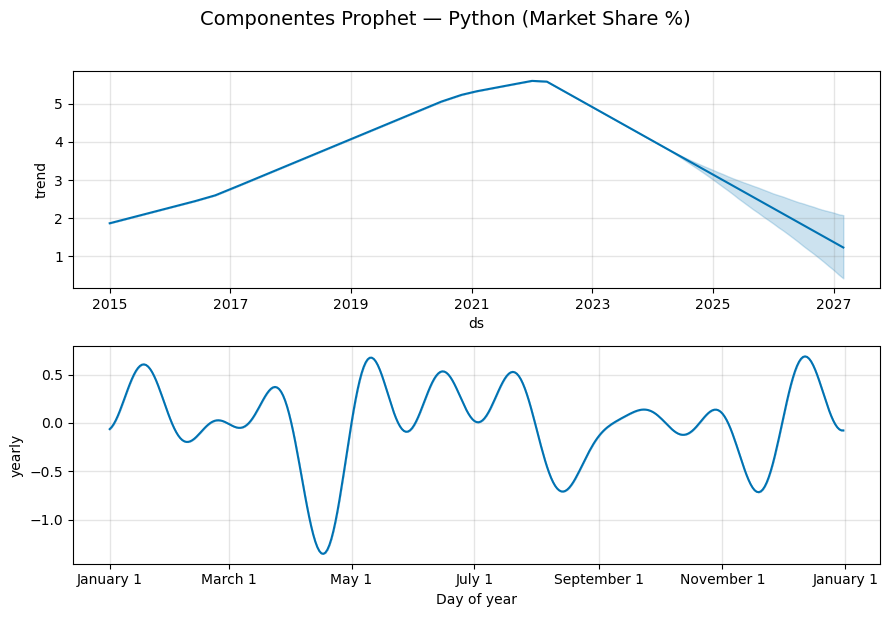

In [14]:
# Descomposicion de componentes para Python
modelo_py = modelos['python']
fc_py_full = modelo_py.predict(
    modelo_py.make_future_dataframe(periods=36, freq='MS')
)

fig_comp = modelo_py.plot_components(fc_py_full)
plt.suptitle('Componentes Prophet — Python (Market Share %)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 5 - Analisis Metodologico

### 5.1 Interpretacion del Intervalo de Confianza

El **intervalo de confianza al 90%** (`yhat_lower` a `yhat_upper`) cuantifica la incertidumbre del modelo.

| Intervalo | Interpretacion | Ejemplo |
|-----------|---------------|--------|
| **Angosto** | Alta certeza: la trayectoria del Market Share es estable y predecible | Tecnologias maduras con alta cuota (Python, JavaScript) |
| **Amplio** | Alta incertidumbre: volatilidad historica elevada o historia corta | Tecnologias emergentes o en transicion (Swift, Vue.js) |

**Puntos clave:**
- Un intervalo amplio **no es un defecto**: es informacion sobre el *riesgo* de la proyeccion.
- El intervalo se ensancha naturalmente a medida que la proyeccion se aleja del ultimo dato observado.
- La estacionalidad anual (ciclos academicos/laborales) produce oscilaciones dentro del intervalo.
- Si `yhat_lower` se mantiene positivo y estable, la tecnologia tiene relevancia garantizada al 90% de confianza.

### 5.2 Limitaciones de Prophet

#### Supuesto fundamental: Continuidad de la tendencia

Prophet es un modelo **extrapolativo**: asume que los patrones historicos de tendencia y estacionalidad continuaran. Esta es su mayor fortaleza y su mayor limitacion:

> **Un cambio de paradigma tecnologico puede invalidar completamente la proyeccion.**

#### Eventos disruptivos no capturados

| Evento | Impacto potencial |
|--------|------------------|
| Adopcion masiva de IA generativa (ChatGPT, Copilot) | Ya esta reduciendo el volumen absoluto de SO; nuestra metrica de Market Share mitiga este efecto pero no lo elimina si la IA afecta desproporcionadamente a ciertos lenguajes |
| Lanzamiento de un framework/lenguaje disruptivo | Podria redistribuir Market Share de forma no lineal |
| Cambios en la politica de Stack Overflow | Moderacion, gamificacion o restricciones de IA podrian alterar los patrones de publicacion |
| Crisis economica o regulatoria | Alteraria la demanda de talento tech en LATAM |

#### Responsabilidad metodologica

Estas proyecciones son **escenarios condicionales**: *"Si las condiciones actuales del Market Share se mantienen, entonces..."*. Deben usarse como:

1. **Indicadores de direccion**, no predicciones deterministas.
2. **Complemento** a encuestas de mercado laboral, Google Trends y reportes de GitHub/JetBrains.
3. **Insumo para debate curricular**, no justificacion unica para cambios de silabo.

El uso del Market Share en lugar del volumen absoluto ya representa un acto de responsabilidad metodologica: reconocemos explicitamente el efecto IA sobre la plataforma y lo neutralizamos.

---

## 6 - Exportacion de Resultados

Consolidamos las proyecciones futuras (solo meses 2025-2027) de todos los tags en un unico DataFrame de Polars y lo exportamos como `forecasts.parquet`.
Generamos tambien una tabla resumen con el Market Share proyectado a **diciembre de 2027**.

In [15]:
# Consolidar proyecciones futuras en un unico DataFrame
frames = []

for tag in TAGS_FORECAST:
    fc = forecasts[tag]
    # Filtrar solo fechas futuras (posteriores al ultimo dato historico)
    last_hist = df_market_share.filter(
        pl.col('Tag') == tag
    )['YearMonth'].max()
    
    fc_future = fc[fc['ds'] > last_hist][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    fc_future['tag'] = tag
    frames.append(fc_future)

df_forecasts_pd = pd.concat(frames, ignore_index=True)

# Convertir a Polars con columnas limpias
df_forecasts = pl.from_pandas(df_forecasts_pd).select(
    'tag',
    pl.col('ds').cast(pl.Date),
    pl.col('yhat').round(4),
    pl.col('yhat_lower').round(4),
    pl.col('yhat_upper').round(4),
)

print(f'Consolidado de forecasts: {df_forecasts.shape}')
display(df_forecasts.head(10))

Consolidado de forecasts: (252, 5)


tag,ds,yhat,yhat_lower,yhat_upper
str,date,f64,f64,f64
"""python""",2024-04-01,3.7951,3.5989,4.0081
"""python""",2024-05-01,3.7717,3.5672,3.9733
"""python""",2024-06-01,3.6463,3.4413,3.8395
"""python""",2024-07-01,3.6051,3.4005,3.8026
"""python""",2024-08-01,3.4137,3.2118,3.6295
"""python""",2024-09-01,3.3172,3.1021,3.5407
"""python""",2024-10-01,3.419,3.2201,3.6302
"""python""",2024-11-01,3.3817,3.154,3.6017
"""python""",2024-12-01,3.2756,3.0421,3.5073


In [16]:
# Tabla resumen: Market Share proyectado a diciembre 2027
from datetime import date

df_dic2027 = df_forecasts.filter(
    pl.col('ds') == date(2027, 12, 1)
).sort('yhat', descending=True)

print('--- Market Share Proyectado — Diciembre 2027 (IC 90%) ---')
display(
    df_dic2027.to_pandas()
    .style
    .format({'yhat': '{:.3f}%', 'yhat_lower': '{:.3f}%', 'yhat_upper': '{:.3f}%'})
    .background_gradient(cmap='RdYlGn', subset=['yhat'])
    .set_caption('Market Share proyectado (%) — Diciembre 2027')
)

--- Market Share Proyectado — Diciembre 2027 (IC 90%) ---


,tag,ds,yhat,yhat_lower,yhat_upper


In [17]:
# Exportar a parquet
os.makedirs(OUT_DIR, exist_ok=True)
output_path = os.path.join(OUT_DIR, 'forecasts.parquet')
df_forecasts.write_parquet(output_path)

print(f'Forecasts exportados: {output_path}')
print(f'  Filas: {df_forecasts.shape[0]:,}')
print(f'  Tags: {df_forecasts["tag"].unique().to_list()}')

Forecasts exportados: ../data/datos_procesados/eda\forecasts.parquet
  Filas: 252
  Tags: ['node.js', 'reactjs', 'c#', 'python', 'swift', 'angular', 'php']


---

> **Siguiente paso:** En la **Fase 5** (Informe Final), estas proyecciones de Market Share se integraran con el analisis de mercado laboral LATAM para formular recomendaciones curriculares concretas. El archivo `forecasts.parquet` sera consumido por el dashboard Streamlit para el componente de visualizacion predictiva.